# 01 · What "closure" means, computed exactly on toy systems

**Project:** *Where Does the Software End? Decisive tests of computational closure in a whole nervous system* (Kempner proposal, §3)

Before measuring closure in a worm, we need the measures to behave correctly where the answer is known. Here the "brain" is a finite Markov chain $X_t$ over micro states, and a candidate "software" level is a coarse-graining $Z_t = f(X_t)$ that groups micro states into macro blocks.

Following Rosas et al. (2024), a macro level can be self-contained in three senses:

| Notion | Question | Quantity computed here |
|---|---|---|
| **Informational closure** | Does micro detail add *predictive* information about the macro future, beyond the macro past? | $I(Z_{t+1}; X_t \mid Z_{t-k+1:t})$ at stationarity |
| **Causal closure** | If we *intervene* on the micro state, does the macro future depend only on which block we put it in? | mean KL of $P(Z' \mid do(X{=}x))$ from the block average |
| **Computational closure** | Is the macro level's own predictive machine (its ε-machine) unrefined by micro detail when predicting the macro *future*? | expected TV distance between macro-history predictions and the predictions of compatible micro states |

The third column is this project's operationalization; check the paper for the exact theorems that relate the three notions.

**What this notebook establishes:**
1. The exact measures are zero exactly when they should be.
2. Observational closure can hold while causal closure fails. This is why the project uses the *interventional* signal-propagation atlas, not only spontaneous activity.
3. Closure is graded, which motivates the "compression cost of computation" curve.
4. A finite-data estimator (held-out predictive gain of adding micro information) recovers the exact quantity. This is the same logic the L0→L4 model ladder applies at scale.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import numpy as np, matplotlib.pyplot as plt
from closurebench import discrete as d
rng = np.random.default_rng(0)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1 · Three worlds with known answers

* **Closed:** a *strongly lumpable* chain. Every micro state in block A has the same probability of jumping to each block B, so the macro level is a Markov chain on its own, under any initial condition.
* **Not closed:** a random chain with the same partition.
* **Hidden state:** the closed chain plus one micro state $x^*$ inside block 0 that the system *never enters on its own*, but which, if forced, behaves differently at the macro level.

In [3]:
partition = [[0, 1, 2], [3, 4], [5]]
P_closed = d.make_strongly_lumpable(partition, rng)
P_random = d.random_chain(6, rng)
P_hidden, part_hidden = d.add_hidden_state(P_closed, partition, block=0, rng=rng)
worlds = {"closed": (P_closed, partition), "not closed": (P_random, partition), "hidden state": (P_hidden, part_hidden)}

print(f"{'world':14s} {'informational (k=1)':>20s} {'informational (k=3)':>20s} {'causal':>8s} {'computational':>14s}")
for name, (P, part) in worlds.items():
    ic1 = d.informational_closure_gap(P, part, k=1)
    ic3 = d.informational_closure_gap(P, part, k=3)
    cc = d.causal_closure_gap(P, part)
    comp, n_eps, n_ups = d.computational_closure_gap(P, part, k=2, L=2)
    print(f"{name:14s} {ic1:20.4f} {ic3:20.4f} {cc:8.4f} {comp:14.4f}   (bits; TV for computational)")

world           informational (k=1)  informational (k=3)   causal  computational
closed                       0.0000               0.0000   0.0000         0.0000   (bits; TV for computational)
not closed                   0.0963               0.0848   0.1046         0.1317   (bits; TV for computational)
hidden state                 0.0000               0.0000   0.0751         0.0000   (bits; TV for computational)


**Reading the table.** The hidden-state world is closed by every *observational* criterion, because the deviant micro state has zero stationary probability. Only an intervention, forcing the system into $x^*$, exposes that the macro level is not self-contained.

In the worm, the analogue is a mechanism that is silent during spontaneous activity but shapes the response to perturbation; slow neuropeptide signalling is a natural candidate. This is the formal reason E1 is scored on **held-out single-neuron stimulations** (Randi et al. 2023) and not on spontaneous activity alone.

## 2 · Closure is graded: interpolating from closed to not closed

Mix a closed chain with a random one: $P_\lambda = (1-\lambda)P_{closed} + \lambda P_{random}$. Every gap should grow smoothly from 0. This is the toy version of the claim that reducibility is a continuum.

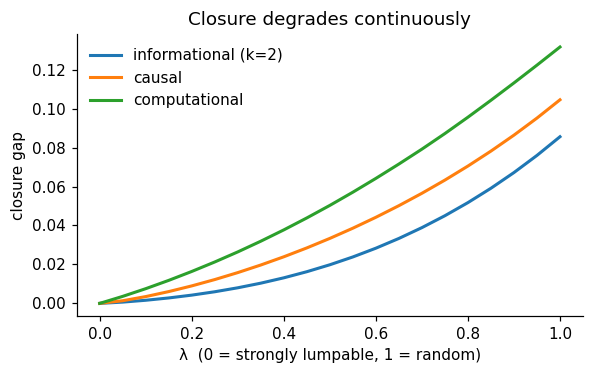

In [4]:
lams = np.linspace(0, 1, 21)
curves = {"informational (k=2)": [], "causal": [], "computational": []}
for lam in lams:
    P = (1 - lam) * P_closed + lam * P_random
    curves["informational (k=2)"].append(d.informational_closure_gap(P, partition, k=2))
    curves["causal"].append(d.causal_closure_gap(P, partition))
    curves["computational"].append(d.computational_closure_gap(P, partition, k=2, L=2)[0])
fig, ax = plt.subplots(figsize=(5.5, 3.5))
for k, v in curves.items():
    ax.plot(lams, v, label=k, lw=2)
ax.set_xlabel("λ  (0 = strongly lumpable, 1 = random)"); ax.set_ylabel("closure gap")
ax.legend(frameon=False); ax.set_title("Closure degrades continuously"); plt.tight_layout(); plt.show()

## 3 · Many random coarse-grainings: how often is a level closed by chance?

For random chains, closure is non-generic. Finding a closed level in a real system is therefore informative, and the ladder must be able to report "no level closes" (proposal outcome C).

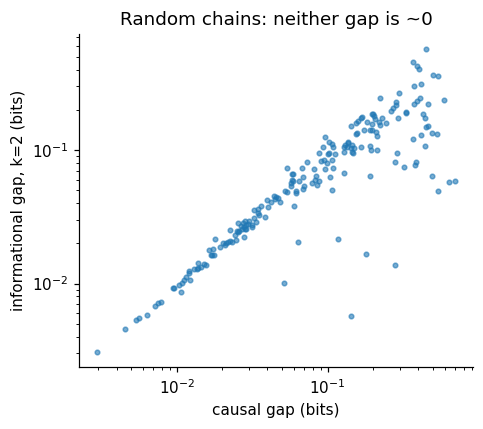

fraction with informational gap < 1e-3: 0.0


In [5]:
rows = []
for trial in range(200):
    n = 6
    P = d.random_chain(n, rng, concentration=rng.choice([0.2, 1.0, 5.0]))
    perm = rng.permutation(n); cut = sorted(rng.choice(np.arange(1, n), 2, replace=False))
    part = [list(b) for b in np.split(perm, cut)]
    rows.append((d.informational_closure_gap(P, part, k=2), d.causal_closure_gap(P, part)))
rows = np.array(rows)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.loglog(rows[:, 1] + 1e-6, rows[:, 0] + 1e-6, ".", alpha=0.6)
ax.set_xlabel("causal gap (bits)"); ax.set_ylabel("informational gap, k=2 (bits)")
ax.set_title("Random chains: neither gap is ~0"); plt.tight_layout(); plt.show()
print("fraction with informational gap < 1e-3:", (rows[:, 0] < 1e-3).mean())

## 4 · From exact quantities to finite data

With finite data we cannot enumerate probabilities, so we estimate closure as **held-out predictive gain**: fit a predictor that sees only the macro history and one that also sees the micro state, then measure the drop in log-loss (bits per step) on unseen data.

* Closed level: the gain → 0, or is slightly negative from overfitting.
* Non-closed level: the gain converges to the exact conditional mutual information.

The model ladder (Notebooks 02 and 04) applies the same logic. Each rung adds micro detail, and we ask whether held-out prediction improves by more than a pre-registered margin.

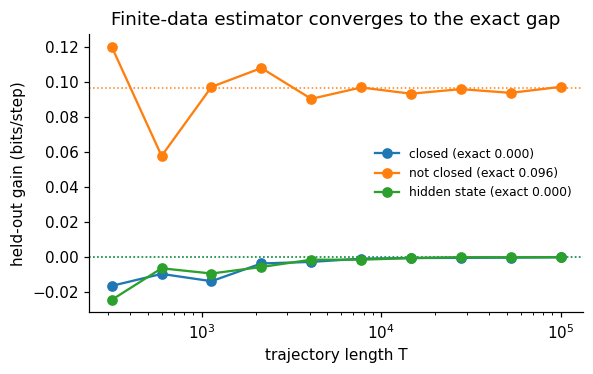

In [6]:
Ts = np.unique(np.logspace(2.5, 5, 10).astype(int))
fig, ax = plt.subplots(figsize=(5.5, 3.5))
for name, (P, part) in worlds.items():
    exact = d.informational_closure_gap(P, part, k=1)
    est = [np.mean([d.heldout_predictive_gain(d.sample_chain(P, T, rng), part, k=1) for _ in range(5)]) for T in Ts]
    l, = ax.semilogx(Ts, est, "o-", label=f"{name} (exact {exact:.3f})")
    ax.axhline(exact, color=l.get_color(), ls=":", lw=1)
ax.set_xlabel("trajectory length T"); ax.set_ylabel("held-out gain (bits/step)")
ax.legend(frameon=False, fontsize=8); ax.set_title("Finite-data estimator converges to the exact gap")
plt.tight_layout(); plt.show()

The observational estimator converges to the exact *informational* gap for all three worlds, and it reports ≈0 for the hidden-state world, where the *causal* gap is not zero. In a real system, then, passive data can certify only informational closure. Causal closure needs perturbations.

## 5 · What carries forward

| Toy result | Consequence for the worm |
|---|---|
| Interventions reveal hidden non-closure | Score the ladder on held-out optogenetic stimulations; use unc-31 as a second intervention that deletes peptide release |
| Closure is graded | Report a compression-cost curve, not a yes/no answer |
| Held-out predictive gain estimates closure | E1's decision rule: deeper rungs must add < 5% of the noise ceiling (bootstrap CI) |
| Closure is non-generic | A null result ("no rung closes") is a real, publishable outcome (C) |

**Possible extensions:** compute ε-machines with CSSR-style history clustering for non-Markov macro processes; add the υ-machine construction from Rosas et al. explicitly; test multi-level hierarchies (a macro-of-a-macro).